# Import

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tikzplotlib

# Results directory

In [2]:
RESULTS_DIR = Path("results/time_per_it_4")

# File

In [3]:
DATA = RESULTS_DIR / "compromise_results.csv"
COLLECTIVE = RESULTS_DIR / "collective_results.csv"
PATH = RESULTS_DIR / "path_results.csv"

# Read files

In [4]:
df = pd.read_csv(DATA)
df_collective = pd.read_csv(COLLECTIVE)
df_path = pd.read_csv(PATH)

In [5]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,0,1,0,2,0,0,10,True,...,False,NaN,0,0,1,True,0,0,2.034823,0.0
1,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,2.088095,0.0
2,3,100,5,1,5,2,0,5,10,True,...,False,NaN,5,5,1,True,5,0,2.118458,1.0
3,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,True,1,0,2.227264,0.0
4,3,100,4,1,4,2,0,4,10,True,...,False,NaN,4,4,1,True,4,0,2.313713,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,3,100,44,3,44,2,0,44,50,True,...,False,NaN,44,44,1,True,44,0,0.000000,inf
926,3,100,30,3,30,2,0,30,30,True,...,False,NaN,30,30,1,True,30,2,237.959758,1.0
927,3,100,49,3,49,2,0,49,50,True,...,False,NaN,49,49,1,True,49,0,0.000000,inf
928,3,100,30,3,30,2,0,30,30,True,...,False,NaN,30,30,1,True,30,3,130.605073,1.0


In [6]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,0,1,0,2,0,0,10,True,...,False,NaN,0,0,1,True,0,0,2.034823,0.0
1,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,2.088095,0.0
2,3,100,5,1,5,2,0,5,10,True,...,False,NaN,5,5,1,True,5,0,2.118458,1.0
3,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,True,1,0,2.227264,0.0
4,3,100,4,1,4,2,0,4,10,True,...,False,NaN,4,4,1,True,4,0,2.313713,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
925,3,100,44,3,44,2,0,44,50,True,...,False,NaN,44,44,1,True,44,0,0.000000,inf
926,3,100,30,3,30,2,0,30,30,True,...,False,NaN,30,30,1,True,30,2,237.959758,1.0
927,3,100,49,3,49,2,0,49,50,True,...,False,NaN,49,49,1,True,49,0,0.000000,inf
928,3,100,30,3,30,2,0,30,30,True,...,False,NaN,30,30,1,True,30,3,130.605073,1.0


In [7]:
df_path

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Dm_id,Time,Length,Model_Length
0,3,100,0,1,0,2,0,0,10,True,...,0,0,1,True,0,0,0,0.000004,0.0,2.0
1,3,100,2,1,2,2,0,2,10,True,...,2,2,1,True,2,0,1,0.000003,0.0,2.0
2,3,100,2,1,2,2,0,2,10,True,...,2,2,1,True,2,0,0,0.000004,0.0,2.0
3,3,100,4,1,4,2,0,4,10,True,...,4,4,1,True,4,0,1,0.000003,1.0,2.0
4,3,100,5,1,5,2,0,5,10,True,...,5,5,1,True,5,0,1,0.000002,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,3,100,30,3,30,2,0,30,30,True,...,30,30,1,True,30,1,0,0.206430,1.0,3.0
1504,3,100,30,3,30,2,0,30,30,True,...,30,30,1,True,30,2,0,0.000001,1.0,2.0
1505,3,100,30,3,30,2,0,30,30,True,...,30,30,1,True,30,2,1,0.000001,1.0,2.0
1506,3,100,30,3,30,2,0,30,30,True,...,30,30,1,True,30,3,1,0.000001,1.0,2.0


# New attributes

In [8]:
df["Gen"] = np.array(["Homogene", "Heterogene"])[df["Group"] % 2]
df["Accept"] = np.array(["Conservative", "Tolerant"])[df["Group"] % 2]

df["Changes_Prop"] = df["Changes"] / (df["N_bc"] * df["Group_size"])

df_collective["Objective_Prop"] = df_collective["Objective"] / df_collective["N_bc"]

# Filter

In [9]:
# dff = df[df["Fitness_train"] == 1]
# dff = df[df["N_tr"].isin([10, 20, 30, 80, 90, 100])]
# dff = df[df["N_tr"] % 20 == 0]
dff = df
dff = dff[~df["Mie"]]
dff = dff.drop(columns=["Mie", "Mie_id"])
# dff = dff[dff["Group_size"] == 2]
dff = dff[dff["Ko"] <= 3]
dff = dff[dff["Gen"] == "Homogene"]
dff = dff[dff["Path"]]
# dff = dff[dff["Compromise"]]

In [10]:
dff

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes,Gen,Accept,Changes_Prop
0,3,100,2,1,2,2,0,2,10,True,...,1,True,2,True,0.737491,1,0,Homogene,Conservative,0.000000
1,3,100,1,1,1,2,0,1,10,True,...,1,True,1,True,0.740762,1,0,Homogene,Conservative,0.000000
2,3,100,11,1,11,2,0,11,10,True,...,1,True,11,True,0.759811,1,0,Homogene,Conservative,0.000000
3,3,100,8,1,8,2,0,8,10,True,...,1,True,8,True,0.814243,1,0,Homogene,Conservative,0.000000
4,3,100,10,1,10,2,0,10,10,True,...,1,True,10,True,0.784825,1,0,Homogene,Conservative,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,3,100,38,3,38,2,0,38,40,True,...,1,True,38,False,300.283753,1,0,Homogene,Conservative,0.000000
565,3,100,30,3,30,2,0,30,20,True,...,1,True,30,False,308.355225,7,0,Homogene,Conservative,0.000000
566,3,100,28,3,28,2,0,28,50,True,...,1,True,28,True,0.711171,1,0,Homogene,Conservative,0.000000
567,3,100,39,3,39,2,0,39,50,True,...,1,True,39,True,0.919654,1,0,Homogene,Conservative,0.000000


# Merge data

In [11]:
# df = pd.merge(
#     df_mip,
#     df_path,
#     how="left",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mc_id",
#         "Path",
#         "P_id",
#         "It"
#     ],
#     suffixes=["_mip", "_path"],
# )


df_compromise_path = dff[dff["Path"]]
df_compromise_path = df_compromise_path[df_compromise_path["Compromise"]]
df_compromise_path_index = df_compromise_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)
df_compromise_no_path = dff[~dff["Path"]]
df_compromise_no_path = df_compromise_no_path[df_compromise_no_path["Compromise"]]
df_compromise_no_path_index = df_compromise_no_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)

df_compromise_index = pd.merge(
    df_compromise_path_index,
    df_compromise_no_path_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
)

df_compromise_path = pd.merge(
    df_compromise_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

df_compromise_no_path = pd.merge(
    df_compromise_no_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

# df_compromise = pd.merge(
#     df_compromise_path,
#     df_compromise_no_path,
#     how="inner",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mie",
#         "P_id",
#         "Mie_id",
#         "Mc_id",
#         "P_id",
#         "Gen",
#         "Accept"
#     ],
#     suffixes=["_path", "_no_path"],
# )

df_compromise = pd.concat([df_compromise_path, df_compromise_no_path])

df_compromise

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Changes,Gen,Accept,Changes_Prop,Method_x,Mie_config_x,Nb_Mcp_x,Method_y,Mie_config_y,Nb_Mcp_y


# Plot

Text(0.5, 0.98, 'Proportion of instances reaching compromise')

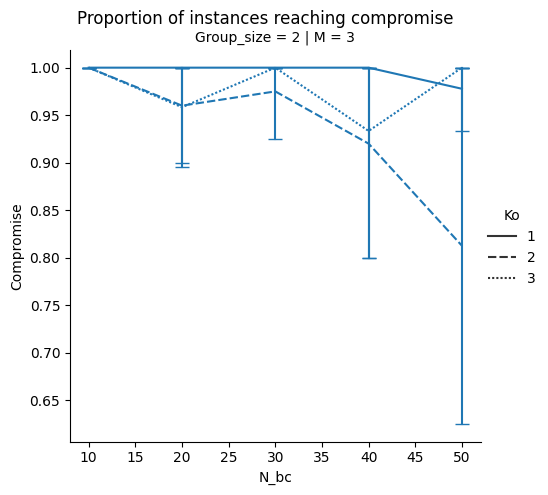

In [12]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Compromise",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise")

Text(0.5, 0.98, 'Computing time for collective model (MILP)')

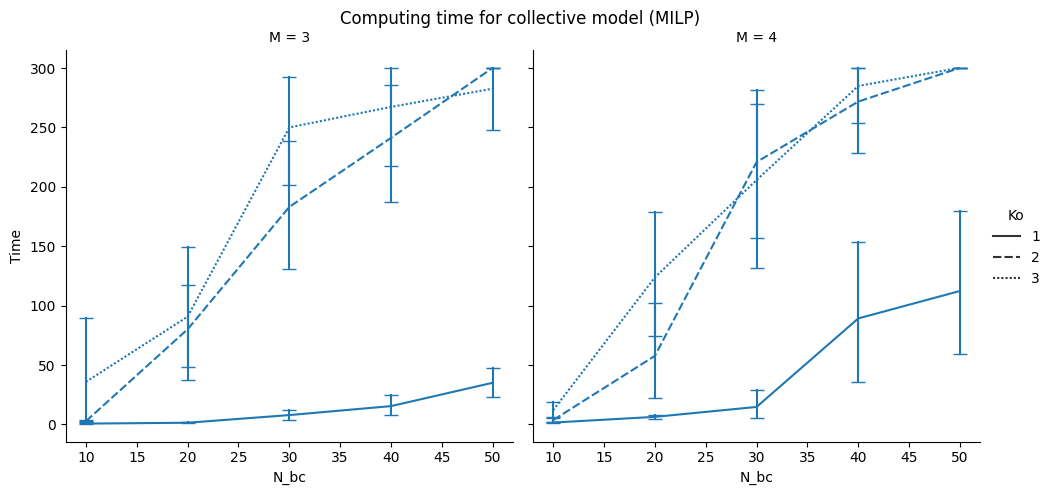

In [38]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")

Text(0.5, 0.98, 'Computing time for preference path')

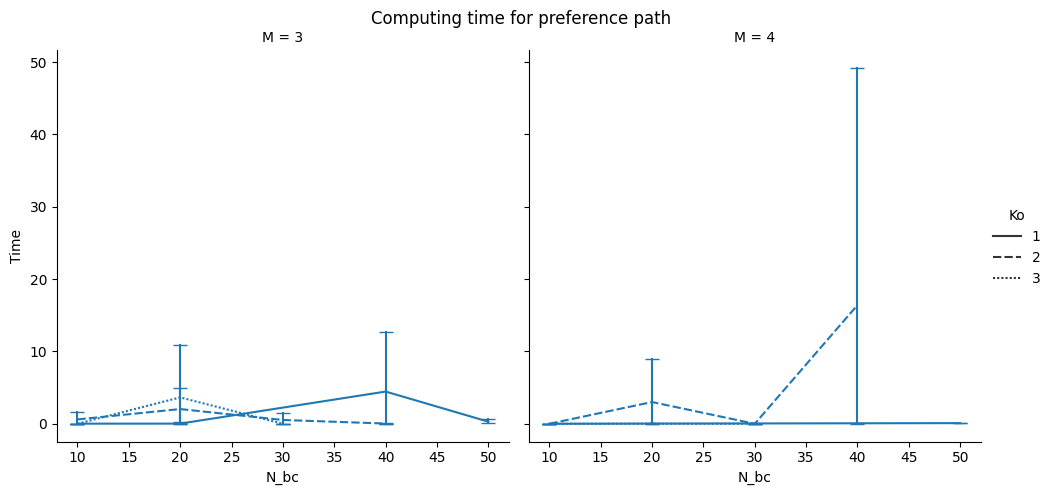

In [36]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for preference path")

Text(0.5, 0.98, 'Number of iterations')

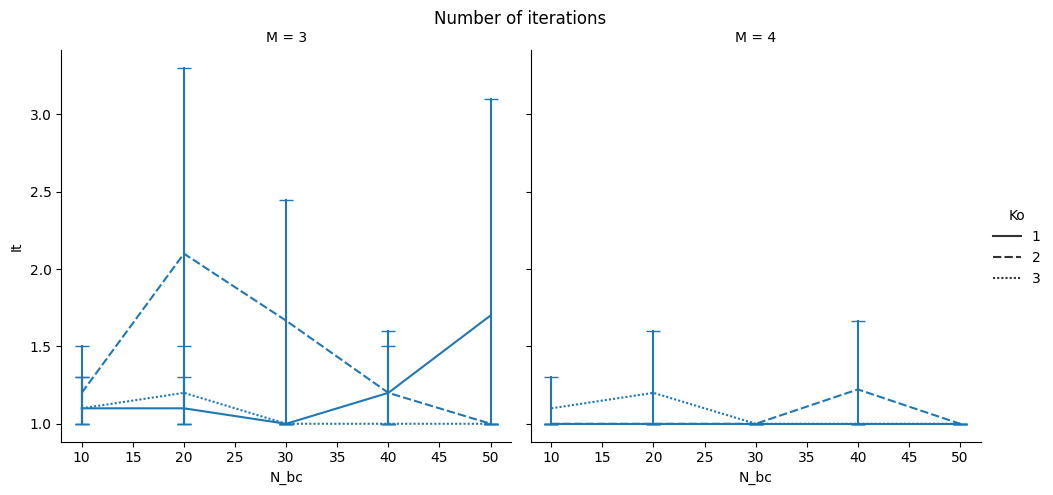

In [24]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="It",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")

Text(0.5, 0.98, 'Max number of comparisons to change for DMs')

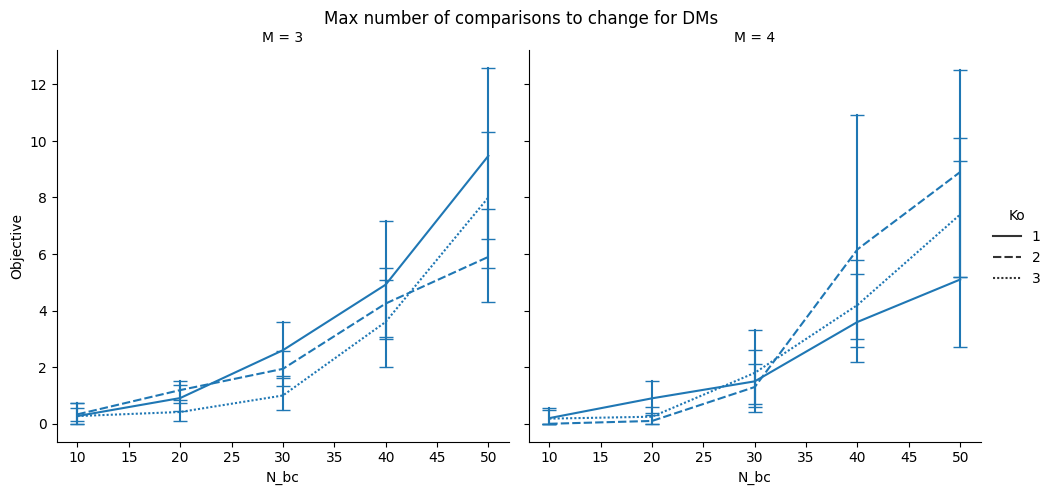

In [37]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")

Text(0.5, 0.98, 'Max proportion of comparisons to change for DMs')

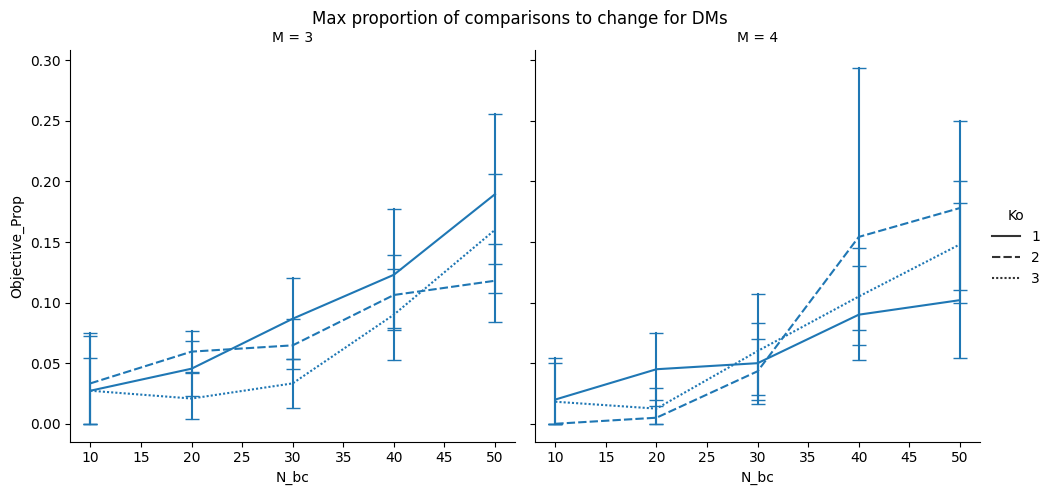

In [31]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max proportion of comparisons to change for DMs")